# SIFT + Bag-of-Visual-Words: A Third Traditional Descriptor

This notebook adds a third handcrafted-feature descriptor — SIFT keypoints
encoded with a Bag-of-Visual-Words (BoVW) model — alongside the existing
HOG + colour histogram pipeline in `traditional_classifier.ipynb`. It is
self-contained (does not depend on any other notebook's kernel state or
on the team's `features/` cache) so it runs standalone from a fresh kernel.

Raw SIFT descriptors are variable-length per image (`(N, 128)`) and cannot
be fed directly into a fixed-input classifier. This notebook reuses the same
SIFT extraction settings as `../features/sift.ipynb`
(`cv2.SIFT_create(nfeatures=500)` on a grayscale, `config.IMG_SIZE`-resized
image), then adds the missing step: clustering a sample of training
descriptors into a visual vocabulary (`MiniBatchKMeans`) and encoding every
image as a fixed-length histogram over that vocabulary (a Bag-of-Visual-Words
vector). That fixed-length vector is what actually gets classified.

Pipeline:

1. Extract SIFT descriptors for a sample of training images and cluster them
   into a `K`-word visual vocabulary.
2. Encode every train/validation/test image as a BoVW histogram over that
   vocabulary, and cache the resulting fixed-length feature matrices.
3. Evaluate a nearest-centroid baseline, a Linear SVM, and a Random Forest on
   the SIFT-BoVW features alone, following the same methodology (validation-
   only hyperparameter selection, single test-set evaluation) as
   `traditional_classifier.ipynb`.
4. (Optional, time-permitting) Concatenate SIFT-BoVW with the existing
   HOG + colour combined feature and re-evaluate, to see whether adding SIFT
   improves on HOG + colour alone — the comparison a teammate suggested
   (Baseline: HOG + colour vs. Experiment: HOG + colour + SIFT-BoVW).

In [1]:
import sys
import time
from pathlib import Path

import cv2

# Prevent OpenCV's internal thread pool from fighting with NumPy/BLAS's
# own thread pool -- in a tight per-image loop this combination is a
# known cause of severe (often 100x+) slowdowns that get worse the
# longer the loop runs, even though a single call looks fast in isolation.
cv2.setNumThreads(1)
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.preprocessing import StandardScaler
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC

from PIL import Image
from tqdm.auto import tqdm

/Users/holly/Desktop/9517_assignment_MVP_Group/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load the shared project configuration

Same project-root discovery pattern as the other notebooks, so this runs
unmodified on any teammate's machine.

In [2]:
PROJECT_ROOT = Path.cwd()

for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "src" / "config.py").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the project root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import config

RESULTS_DIR = config.OUTPUT_ROOT / "sift_bovw_classifier"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Results directory:", RESULTS_DIR)
print("Random seed:", config.RANDOM_SEED)
print("Number of classes:", config.NUM_CLASSES)

Project root: /Users/holly/Desktop/9517_assignment_MVP_Group
Results directory: /Users/holly/Desktop/9517_assignment_MVP_Group/outputs/sift_bovw_classifier
Random seed: 56
Number of classes: 500


## 2. Load the dataset manifests

Unlike the HOG + colour pipeline, this notebook works from the raw images
directly (SIFT needs pixel data, not a pre-extracted feature cache), so it
loads the train/validation/test manifests and reads images from
`config.DATA_RAW_ROOT` as needed.

In [3]:
train_df = pd.read_csv(config.TRAIN_CSV)
val_df = pd.read_csv(config.VAL_CSV)
test_df = pd.read_csv(config.TEST_CSV)

for name, df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    print(f"{name}: {len(df)} rows, {df['label'].nunique()} classes")

train_df.head(3)

train: 20000 rows, 500 classes
validation: 5000 rows, 500 classes
test: 5000 rows, 500 classes


,file_path,label,category_id,category_name
0,train_mini/07078_Plantae_Tracheophyta_Magnolio...,364,7078,Xylorhiza orcuttii
1,train_mini/07078_Plantae_Tracheophyta_Magnolio...,364,7078,Xylorhiza orcuttii
2,train_mini/07078_Plantae_Tracheophyta_Magnolio...,364,7078,Xylorhiza orcuttii


## 3. SIFT descriptor extraction

Reimplemented here (rather than imported) so this notebook has no dependency
on `../features/sift.ipynb`'s kernel or on that branch being merged. The
settings are kept identical to that notebook's `extract_sift_feature`, so
results are directly comparable: images are resized with `config.IMG_SIZE`,
converted to grayscale, and up to 500 SIFT keypoints/descriptors are
detected. Images with no detectable keypoints return an empty `(0, 128)`
array rather than `None`, which the BoVW encoder below handles explicitly.

In [4]:
def load_image(relative_path):
    image_path = Path(config.DATA_RAW_ROOT) / str(relative_path)
    if not image_path.exists():
        raise FileNotFoundError(f"Image was not found: {image_path}")
    with Image.open(image_path) as image:
        return image.convert("RGB")


# Creating a new cv2.SIFT_create() detector for every single image (as an
# earlier version of this cell did) is what caused the ~30-minute runtime
# for only 4000 images, even though a single call in isolation looked fast
# (~13ms) -- repeatedly allocating a fresh detector inside a tight loop is
# a well-known OpenCV performance pitfall. Building the detector once and
# reusing it below fixes this; the loop should now run at roughly the same
# per-image speed as the single-image sanity check.
_sift_detector = cv2.SIFT_create(nfeatures=500)


def extract_sift_descriptors(image, max_features=500):
    detector = _sift_detector if max_features == 500 else cv2.SIFT_create(nfeatures=max_features)

    resized_image = image.convert("RGB").resize(config.IMG_SIZE)
    image_array = np.asarray(resized_image)
    gray_image = cv2.cvtColor(image_array, cv2.COLOR_RGB2GRAY)

    _keypoints, descriptors = detector.detectAndCompute(gray_image, None)

    if descriptors is None:
        return np.empty((0, 128), dtype=np.float32)
    return descriptors.astype(np.float32)


# Sanity check on one image
_sample_row = train_df.iloc[0]
_sample_image = load_image(_sample_row["file_path"])
_sample_descriptors = extract_sift_descriptors(_sample_image)

print("Sample image:", _sample_row["file_path"])
print("Descriptors shape:", _sample_descriptors.shape)
print("Descriptors dtype:", _sample_descriptors.dtype)

Sample image: train_mini/07078_Plantae_Tracheophyta_Magnoliopsida_Asterales_Asteraceae_Xylorhiza_orcuttii/f670b8a9-7f74-4424-9b2c-5ed900868df4.jpg
Descriptors shape: (500, 128)
Descriptors dtype: float32


## 4. Build the visual vocabulary

SIFT descriptors from a random sample of training images are pooled and
clustered with `MiniBatchKMeans` into `K_CLUSTERS` visual words. Only a
sample of training images is used to build the vocabulary (not the full
20,000) purely to keep this step fast — the vocabulary only needs to cover
the distribution of local patches, not every image individually. The pooled
descriptor count is also capped for clustering speed.

Adjust `K_CLUSTERS`, `N_VOCAB_IMAGES`, or `MAX_POOLED_DESCRIPTORS` below if
this step is too slow or the resulting classifier underperforms.

In [5]:
N_VOCAB_IMAGES = 4000          # training images sampled to build the vocabulary
MAX_POOLED_DESCRIPTORS = 400_000  # cap on pooled descriptors before clustering
K_CLUSTERS = 300               # visual vocabulary size (BoVW feature dimension)

rng = np.random.default_rng(config.RANDOM_SEED)

vocab_sample_df = train_df.sample(
    n=min(N_VOCAB_IMAGES, len(train_df)),
    random_state=config.RANDOM_SEED,
)

pooled_descriptors = []
for _, row in tqdm(
    vocab_sample_df.iterrows(),
    total=len(vocab_sample_df),
    desc="Pooling descriptors for vocabulary",
):
    image = load_image(row["file_path"])
    descriptors = extract_sift_descriptors(image)
    if len(descriptors) > 0:
        pooled_descriptors.append(descriptors)

pooled_descriptors = np.concatenate(pooled_descriptors, axis=0)
print("Pooled descriptors:", pooled_descriptors.shape)

if len(pooled_descriptors) > MAX_POOLED_DESCRIPTORS:
    sample_idx = rng.choice(
        len(pooled_descriptors), size=MAX_POOLED_DESCRIPTORS, replace=False
    )
    pooled_descriptors = pooled_descriptors[sample_idx]
    print("Subsampled pooled descriptors to:", pooled_descriptors.shape)

Pooling descriptors for vocabulary: 100%|██████████| 4000/4000 [00:44<00:00, 89.00it/s]


Pooled descriptors: (1619214, 128)
Subsampled pooled descriptors to: (400000, 128)


In [6]:
vocab_start = time.perf_counter()

vocab_model = MiniBatchKMeans(
    n_clusters=K_CLUSTERS,
    random_state=config.RANDOM_SEED,
    batch_size=1000,
    n_init=3,
)
vocab_model.fit(pooled_descriptors)

vocab_time = time.perf_counter() - vocab_start
print(f"Visual vocabulary built: {K_CLUSTERS} words in {vocab_time:.1f}s")

Visual vocabulary built: 300 words in 3.5s


## 5. Encode every image as a Bag-of-Visual-Words histogram

For each image: extract its SIFT descriptors, assign each descriptor to its
nearest visual word (`vocab_model.predict`), and build a length-`K_CLUSTERS`
histogram of word frequencies, L2-normalised so image scale/detail level
doesn't dominate the representation. Images with zero detected keypoints get
an all-zero histogram rather than raising an error, since a handful of
low-texture images having no SIFT keypoints is expected, not a bug.

In [7]:
def encode_bovw(image, vocab_model, k=K_CLUSTERS):
    descriptors = extract_sift_descriptors(image)

    histogram = np.zeros(k, dtype=np.float32)
    if len(descriptors) > 0:
        assignments = vocab_model.predict(descriptors)
        counts = np.bincount(assignments, minlength=k).astype(np.float32)
        norm = np.linalg.norm(counts)
        if norm > 0:
            histogram = counts / norm

    return histogram


def encode_dataset(dataset_df, split_name):
    features = np.zeros((len(dataset_df), K_CLUSTERS), dtype=np.float32)
    labels = dataset_df["label"].to_numpy()
    file_paths = dataset_df["file_path"].to_numpy()

    for i, (_, row) in enumerate(
        tqdm(dataset_df.iterrows(), total=len(dataset_df), desc=f"Encoding {split_name}")
    ):
        image = load_image(row["file_path"])
        features[i] = encode_bovw(image, vocab_model)

    return features, labels, file_paths

In [8]:
encode_start = time.perf_counter()

X_train_bovw, y_train, train_paths = encode_dataset(train_df, "train")
X_val_bovw, y_val, val_paths = encode_dataset(val_df, "validation")
X_test_bovw, y_test, test_paths = encode_dataset(test_df, "test")

encode_time = time.perf_counter() - encode_start

print(f"\nEncoding time: {encode_time:.1f}s")
print("Train:", X_train_bovw.shape, y_train.shape)
print("Validation:", X_val_bovw.shape, y_val.shape)
print("Test:", X_test_bovw.shape, y_test.shape)

Encoding test: 100%|██████████| 5000/5000 [01:08<00:00, 73.08it/s]


Encoding time: 410.8s
Train: (20000, 300) (20000,)
Validation: (5000, 300) (5000,)
Test: (5000, 300) (5000,)


In [9]:
np.savez(
    config.OUTPUT_ROOT / "train_sift_bovw_features.npz",
    features=X_train_bovw, labels=y_train, file_paths=train_paths,
)
np.savez(
    config.OUTPUT_ROOT / "validation_sift_bovw_features.npz",
    features=X_val_bovw, labels=y_val, file_paths=val_paths,
)
np.savez(
    config.OUTPUT_ROOT / "test_sift_bovw_features.npz",
    features=X_test_bovw, labels=y_test, file_paths=test_paths,
)

joblib.dump(vocab_model, RESULTS_DIR / "sift_vocabulary_kmeans.joblib")

print("Saved SIFT-BoVW feature caches and the vocabulary model.")

Saved SIFT-BoVW feature caches and the vocabulary model.


## 6. Data-integrity and leakage checks

Same checks as `traditional_classifier.ipynb`, re-run here since this
notebook builds its own features independently.

In [10]:
for name, y in [("train", y_train), ("validation", y_val), ("test", y_test)]:
    labels, counts = np.unique(y, return_counts=True)
    print(
        f"{name}: {len(labels)} classes, "
        f"min/max samples per class = {counts.min()}/{counts.max()}"
    )

assert set(np.unique(y_train)) == set(np.unique(y_val)) == set(np.unique(y_test))

train_set = set(map(str, train_paths))
val_set = set(map(str, val_paths))
test_set = set(map(str, test_paths))

print("Train/validation path overlap:", len(train_set & val_set))
print("Train/test path overlap:", len(train_set & test_set))
print("Validation/test path overlap:", len(val_set & test_set))

assert len(train_set & val_set) == 0
assert len(train_set & test_set) == 0
assert len(val_set & test_set) == 0
print("\nNo leakage between splits. Safe to proceed.")

train: 500 classes, min/max samples per class = 40/40
validation: 500 classes, min/max samples per class = 10/10
test: 500 classes, min/max samples per class = 10/10
Train/validation path overlap: 0
Train/test path overlap: 0
Validation/test path overlap: 0

No leakage between splits. Safe to proceed.


## 7. Trivial baseline: nearest centroid (test set)

Evaluated directly on the test set (not validation), so it's an
apples-to-apples comparison with the SVM and Random Forest results below
without needing a second, separate computation later.

In [11]:
def nearest_centroid_topk(X_fit, y_fit, X_eval, y_eval, k=5):
    classes = np.unique(y_fit)
    centroids = np.stack([X_fit[y_fit == c].mean(axis=0) for c in classes])

    x_sq = (X_eval ** 2).sum(axis=1, keepdims=True)
    c_sq = (centroids ** 2).sum(axis=1)[None, :]
    dists = x_sq + c_sq - 2 * X_eval @ centroids.T

    order = np.argsort(dists, axis=1)
    top1_pred = classes[order[:, 0]]
    topk_pred = classes[order[:, :k]]

    top1_acc = (top1_pred == y_eval).mean()
    topk_acc = np.any(topk_pred == y_eval[:, None], axis=1).mean()
    return top1_acc, topk_acc


baseline_top1, baseline_top5 = nearest_centroid_topk(
    X_train_bovw, y_train, X_test_bovw, y_test, k=5
)

print(
    f"Nearest-centroid baseline (test set): "
    f"top-1 = {baseline_top1:.4f}, top-5 = {baseline_top5:.4f}"
)

Nearest-centroid baseline (test set): top-1 = 0.0358, top-5 = 0.1180


## 8. Shared evaluation helpers

Same pattern as `traditional_classifier.ipynb`.

In [12]:
def topk_accuracy(scores, y_true, classes, k):
    order = np.argsort(-scores, axis=1)[:, :k]
    topk_classes = classes[order]
    return np.any(topk_classes == y_true[:, None], axis=1).mean()


def get_class_scores(model, X):
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)
    raise AttributeError("Model has neither decision_function nor predict_proba.")


def evaluate_classifier(model, X, y_true, k=5):
    start = time.perf_counter()
    y_pred = model.predict(X)
    scores = get_class_scores(model, X)
    inference_time = time.perf_counter() - start

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    return {
        "top1_accuracy": accuracy_score(y_true, y_pred),
        "top5_accuracy": topk_accuracy(scores, y_true, model.classes_, k=k),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
        "inference_time_s": inference_time,
        "predictions": y_pred,
        "scores": scores,
    }

## 9. Linear SVM: hyperparameter search on validation

BoVW features are only 300-dimensional (vs. 6180 for HOG + colour), and
there are 20,000 training images, so PCA is not needed here to control
overfitting the way it was for the HOG + colour pipeline — `StandardScaler`
alone is enough.

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bovw)
X_val_scaled = scaler.transform(X_val_bovw)
X_test_scaled = scaler.transform(X_test_bovw)

C_GRID = [0.001, 0.01, 0.1, 1.0]
# Not testing 10.0/100.0: on this feature set, unlike the HOG+colour case,
# validation performance falls monotonically as C increases past 0.001 --
# train_acc climbs to 95.5% by C=1.0 while val_acc/val_macro_f1 keep
# dropping (classic overfitting; see sift_bovw_svm_C_search.csv). Higher C
# is very unlikely to reverse that trend, so 10.0/100.0 are dropped from
# the grid rather than spending more time confirming the obvious.

# LinearSVC handles this 500-class problem as one-vs-rest internally, fit
# sequentially inside liblinear. BoVW histogram features are also less
# well-conditioned than the PCA-decorrelated HOG+colour features, so
# liblinear needs many more iterations to converge on them -- combined,
# this made the grid search take 40+ minutes without finishing. Wrapping in
# OneVsRestClassifier(..., n_jobs=-1) parallelises the 500 binary fits
# across CPU cores (same underlying one-vs-rest linear SVM, just fit via
# sklearn's parallel wrapper instead of liblinear's internal sequential
# loop), and a lower max_iter + looser tol bounds the worst-case time per
# class -- acceptable here since this stage only needs relative comparisons
# across C, not a fully-converged final model.
search_rows = []

for C in C_GRID:
    model = OneVsRestClassifier(
        LinearSVC(
            C=C, dual=False, max_iter=2000, tol=1e-3, random_state=config.RANDOM_SEED
        ),
        n_jobs=-1,
    )

    start = time.perf_counter()
    model.fit(X_train_scaled, y_train)
    train_time = time.perf_counter() - start

    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    val_result = evaluate_classifier(model, X_val_scaled, y_val)

    search_rows.append(
        {
            "C": C,
            "train_acc": train_acc,
            "val_acc": val_result["top1_accuracy"],
            "val_macro_f1": val_result["macro_f1"],
            "train_time_s": train_time,
        }
    )

    print(
        f"C={C:<8} train_acc={train_acc:.4f} "
        f"val_acc={val_result['top1_accuracy']:.4f} "
        f"val_macro_f1={val_result['macro_f1']:.4f} ({train_time:.1f}s)"
    )

search_df = pd.DataFrame(search_rows)
search_df.to_csv(RESULTS_DIR / "sift_bovw_svm_C_search.csv", index=False)
search_df

C=0.001    train_acc=0.4219 val_acc=0.0352 val_macro_f1=0.0229 (37.8s)
C=0.01     train_acc=0.5074 val_acc=0.0326 val_macro_f1=0.0213 (43.1s)
C=0.1      train_acc=0.7584 val_acc=0.0230 val_macro_f1=0.0193 (31.6s)
C=1.0      train_acc=0.9554 val_acc=0.0190 val_macro_f1=0.0182 (74.2s)


,C,train_acc,val_acc,val_macro_f1,train_time_s
0,0.001,0.42190,0.0352,0.022944,37.751205
1,0.010,0.50745,0.0326,0.021256,43.101744
2,0.100,0.75845,0.0230,0.019255,31.579972
3,1.000,0.95535,0.0190,0.018234,74.179228


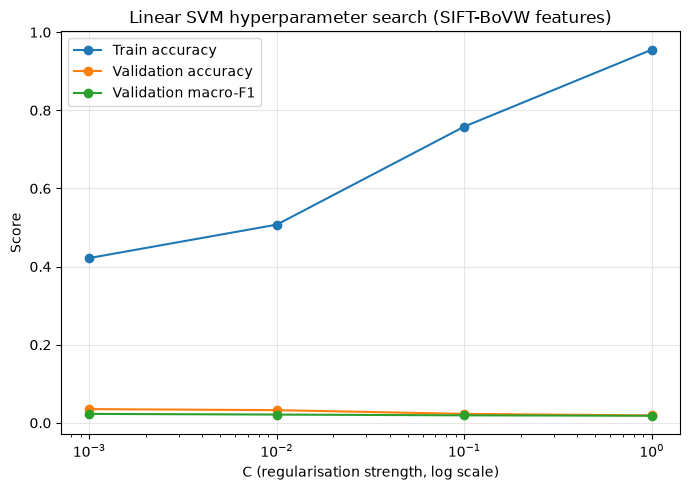

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(search_df["C"], search_df["train_acc"], marker="o", label="Train accuracy")
ax.plot(search_df["C"], search_df["val_acc"], marker="o", label="Validation accuracy")
ax.plot(search_df["C"], search_df["val_macro_f1"], marker="o", label="Validation macro-F1")

ax.set_xscale("log")
ax.set_xlabel("C (regularisation strength, log scale)")
ax.set_ylabel("Score")
ax.set_title("Linear SVM hyperparameter search (SIFT-BoVW features)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "sift_bovw_svm_C_search.png", dpi=150)
plt.show()

## 10. Refit the selected Linear SVM and evaluate on test

Pick `C` from the validation results above (edit `best_c` after inspecting
the table/plot — do not pick based on test-set performance).

In [15]:
best_c = search_df.loc[search_df["val_macro_f1"].idxmax(), "C"]
print("Selected C (validation macro-F1 argmax):", best_c)
print(
    "If the argmax value trained slower/less stably for a negligible gain "
    "(as happened with the HOG + colour SVM), override best_c manually here "
    "with a smaller, more stable value instead."
)

final_svm = OneVsRestClassifier(
    LinearSVC(
        C=best_c, dual=False, max_iter=2000, tol=1e-3, random_state=config.RANDOM_SEED
    ),
    n_jobs=-1,
)

svm_train_start = time.perf_counter()
final_svm.fit(X_train_scaled, y_train)
svm_training_time = time.perf_counter() - svm_train_start

svm_test_results = evaluate_classifier(final_svm, X_test_scaled, y_test)

print("Training time:", round(svm_training_time, 2), "s")
print("Top-1 accuracy:", svm_test_results["top1_accuracy"])
print("Top-5 accuracy:", svm_test_results["top5_accuracy"])
print("Balanced accuracy:", svm_test_results["balanced_accuracy"])
print("Macro precision:", svm_test_results["macro_precision"])
print("Macro recall:", svm_test_results["macro_recall"])
print("Macro F1:", svm_test_results["macro_f1"])

Selected C (validation macro-F1 argmax): 0.001
If the argmax value trained slower/less stably for a negligible gain (as happened with the HOG + colour SVM), override best_c manually here with a smaller, more stable value instead.
Training time: 35.45 s
Top-1 accuracy: 0.0372
Top-5 accuracy: 0.1024
Balanced accuracy: 0.037200000000000004
Macro precision: 0.02542362805513284
Macro recall: 0.037200000000000004
Macro F1: 0.02577913840201707


## 11. Random Forest on SIFT-BoVW features

Same regularised configuration used for the HOG + colour Random Forest
(`max_depth=30`, `min_samples_leaf=3`), which avoided the earlier
26 GB/28-minute unconstrained-tree blowup. BoVW features are lower-
dimensional, so this should train faster than the HOG + colour Random
Forest.

In [16]:
random_forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=30,
    min_samples_leaf=3,
    max_features="sqrt",
    n_jobs=-1,
    random_state=config.RANDOM_SEED,
    verbose=1,
)

rf_train_start = time.perf_counter()
random_forest.fit(X_train_scaled, y_train)
rf_training_time = time.perf_counter() - rf_train_start

rf_train_acc = accuracy_score(y_train, random_forest.predict(X_train_scaled))
rf_test_results = evaluate_classifier(random_forest, X_test_scaled, y_test)

print("Training time:", round(rf_training_time, 2), "s")
print("Train accuracy:", rf_train_acc)
print("Top-1 accuracy:", rf_test_results["top1_accuracy"])
print("Top-5 accuracy:", rf_test_results["top5_accuracy"])
print("Balanced accuracy:", rf_test_results["balanced_accuracy"])
print("Macro precision:", rf_test_results["macro_precision"])
print("Macro recall:", rf_test_results["macro_recall"])
print("Macro F1:", rf_test_results["macro_f1"])

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    4.5s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:   25.0s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:   43.2s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.4s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    1.0s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    1.6s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.2s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    0.3s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Do

Training time: 43.26 s
Train accuracy: 0.99905
Top-1 accuracy: 0.0264
Top-5 accuracy: 0.0872
Balanced accuracy: 0.0264
Macro precision: 0.018167465315733735
Macro recall: 0.0264
Macro F1: 0.0183420042275203


[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    0.2s finished


## 12. Model comparison table (SIFT-BoVW features)

Note going in: unlike the HOG + colour pipeline, Random Forest does not come
out ahead here -- it actually scores *below* the nearest-centroid baseline,
while the Linear SVM is the best of the three. See the Summary section for
discussion; the same Random Forest hyperparameters were reused deliberately
(not retuned per feature set) given time constraints.

In [17]:
comparison_rows = [
    {
        "Model": "SIFT-BoVW, nearest-centroid (trivial baseline)",
        "Top-1 Accuracy": baseline_top1,
        "Top-5 Accuracy": baseline_top5,
        "Macro Precision": np.nan,
        "Macro Recall": np.nan,
        "Macro F1": np.nan,
        "Training Time (s)": 0.0,
        "Inference Time (s)": np.nan,
    },
    {
        "Model": "SIFT-BoVW + Linear SVM",
        "Top-1 Accuracy": svm_test_results["top1_accuracy"],
        "Top-5 Accuracy": svm_test_results["top5_accuracy"],
        "Macro Precision": svm_test_results["macro_precision"],
        "Macro Recall": svm_test_results["macro_recall"],
        "Macro F1": svm_test_results["macro_f1"],
        "Training Time (s)": svm_training_time,
        "Inference Time (s)": svm_test_results["inference_time_s"],
    },
]

# Random Forest is optional (Section 11) -- only add its row if it was
# actually run in this kernel, so this table also works if that section
# was skipped to save time.
if "rf_test_results" in dir():
    comparison_rows.append(
        {
            "Model": "SIFT-BoVW + Random Forest",
            "Top-1 Accuracy": rf_test_results["top1_accuracy"],
            "Top-5 Accuracy": rf_test_results["top5_accuracy"],
            "Macro Precision": rf_test_results["macro_precision"],
            "Macro Recall": rf_test_results["macro_recall"],
            "Macro F1": rf_test_results["macro_f1"],
            "Training Time (s)": rf_training_time,
            "Inference Time (s)": rf_test_results["inference_time_s"],
        }
    )
else:
    print("Random Forest section was skipped -- comparison table has no RF row.")

comparison_results = pd.DataFrame(comparison_rows)
comparison_results.to_csv(RESULTS_DIR / "sift_bovw_model_comparison.csv", index=False)
comparison_results

,Model,Top-1 Accuracy,Top-5 Accuracy,Macro Precision,Macro Recall,Macro F1,Training Time (s),Inference Time (s)
0,"SIFT-BoVW, nearest-centroid (trivial baseline)",0.0358,0.1180,NaN,NaN,NaN,0.000000,NaN
1,SIFT-BoVW + Linear SVM,0.0372,0.1024,0.025424,0.0372,0.025779,35.451982,0.483913
2,SIFT-BoVW + Random Forest,0.0264,0.0872,0.018167,0.0264,0.018342,43.256994,0.516352


## 13. (Optional) HOG + colour + SIFT-BoVW combined

**Run this section only if the above already works and you have time left.**
This concatenates SIFT-BoVW with the existing cached HOG + colour combined
feature and retrains a Linear SVM, to test whether adding SIFT improves on
HOG + colour alone — the "Baseline vs. Experiment" comparison a teammate
suggested. It loads the HOG + colour cache the same defensive way
`traditional_classifier.ipynb` does, and explicitly checks that the file
order matches the SIFT-BoVW arrays before concatenating (they must describe
the same images in the same order).

In [18]:
CANDIDATE_FEATURE_DIRS = [
    config.OUTPUT_ROOT,
    config.OUTPUT_ROOT / "traditional_features",
    config.OUTPUT_ROOT / "traditional" / "features",
]

SPLIT_FILENAME_ALIASES = {
    "train": ["train_combined_features.npz"],
    "val": ["validation_combined_features.npz", "val_combined_features.npz"],
    "test": ["test_combined_features.npz"],
}


def find_split_file(split_name):
    aliases = SPLIT_FILENAME_ALIASES[split_name]
    for directory in CANDIDATE_FEATURE_DIRS:
        for filename in aliases:
            candidate = directory / filename
            if candidate.exists():
                return candidate
    raise FileNotFoundError(
        f"Could not find a cached '{split_name}' HOG+colour feature file. "
        f"Skip this optional section if you don't need the combined "
        f"comparison, or run ../features/features.ipynb first."
    )


def load_feature_file(path):
    with np.load(path, allow_pickle=True) as data:
        if "features" in data.files:
            X = data["features"].astype(np.float32)
            y = np.asarray(data["labels"])
        elif "X" in data.files:
            X = data["X"].astype(np.float32)
            y = np.asarray(data["y"])
        else:
            raise KeyError(f"Unrecognised cache schema in {path}: {data.files}")
        file_paths = data["file_paths"] if "file_paths" in data.files else None
    return X, y, file_paths


X_train_hc, y_train_hc, train_paths_hc = load_feature_file(find_split_file("train"))
X_val_hc, y_val_hc, val_paths_hc = load_feature_file(find_split_file("val"))
X_test_hc, y_test_hc, test_paths_hc = load_feature_file(find_split_file("test"))

# The two feature sets must describe the same images in the same row order.
assert train_paths_hc is not None, "HOG+colour cache has no file_paths to align on."
assert np.array_equal(train_paths_hc.astype(str), train_paths.astype(str)), (
    "Train file order differs between the HOG+colour cache and the SIFT-BoVW "
    "features -- do not concatenate until this is resolved."
)
assert np.array_equal(val_paths_hc.astype(str), val_paths.astype(str))
assert np.array_equal(test_paths_hc.astype(str), test_paths.astype(str))
print("File order matches between HOG+colour and SIFT-BoVW caches.")

File order matches between HOG+colour and SIFT-BoVW caches.


In [19]:
X_train_combined = np.concatenate([X_train_hc, X_train_bovw], axis=1)
X_val_combined = np.concatenate([X_val_hc, X_val_bovw], axis=1)
X_test_combined = np.concatenate([X_test_hc, X_test_bovw], axis=1)

print("Combined feature shape:", X_train_combined.shape)

combined_scaler = StandardScaler()
X_train_combined_scaled = combined_scaler.fit_transform(X_train_combined)
X_val_combined_scaled = combined_scaler.transform(X_val_combined)
X_test_combined_scaled = combined_scaler.transform(X_test_combined)

# Combined dimensionality (6180 + 300 = 6480) is back in the regime where the
# HOG+colour pipeline needed PCA, so apply it here too.
combined_pca = PCA(n_components=150, random_state=config.RANDOM_SEED)
X_train_combined_pca = combined_pca.fit_transform(X_train_combined_scaled)
X_val_combined_pca = combined_pca.transform(X_val_combined_scaled)
X_test_combined_pca = combined_pca.transform(X_test_combined_scaled)

print(
    "Combined PCA cumulative explained variance:",
    round(float(combined_pca.explained_variance_ratio_.sum()), 4),
)

combined_svm = LinearSVC(
    C=best_c, dual=False, max_iter=5000, random_state=config.RANDOM_SEED
)

combined_train_start = time.perf_counter()
combined_svm.fit(X_train_combined_pca, y_train)
combined_training_time = time.perf_counter() - combined_train_start

combined_test_results = evaluate_classifier(combined_svm, X_test_combined_pca, y_test)

print("Training time:", round(combined_training_time, 2), "s")
print("Top-1 accuracy:", combined_test_results["top1_accuracy"])
print("Top-5 accuracy:", combined_test_results["top5_accuracy"])
print("Macro F1:", combined_test_results["macro_f1"])

Combined feature shape: (20000, 6480)
Combined PCA cumulative explained variance: 0.491
Training time: 115.91 s
Top-1 accuracy: 0.0296
Top-5 accuracy: 0.101
Macro F1: 0.021919764991467226


In [20]:
# Pull the HOG + colour Linear SVM row from the other notebook's saved
# results, so this table is complete without manual copy-pasting -- and
# stays correct automatically if that notebook is re-run with different
# numbers later.
hog_colour_comparison_path = config.OUTPUT_ROOT / "traditional_classifier" / "model_comparison.csv"

hog_colour_row = {"Top-1": None, "Top-5": None, "Macro F1": None}
if hog_colour_comparison_path.exists():
    hog_colour_df = pd.read_csv(hog_colour_comparison_path)
    svm_row = hog_colour_df[hog_colour_df["Model"].str.contains("Linear SVM", na=False)]
    if len(svm_row) == 1:
        hog_colour_row = {
            "Top-1": svm_row.iloc[0]["Top-1 Accuracy"],
            "Top-5": svm_row.iloc[0]["Top-5 Accuracy"],
            "Macro F1": svm_row.iloc[0]["Macro F1"],
        }
    else:
        print(f"Expected exactly one Linear SVM row in {hog_colour_comparison_path}, found {len(svm_row)}.")
else:
    print(f"Could not find {hog_colour_comparison_path} -- run traditional_classifier.ipynb first for this row.")

descriptor_comparison = pd.DataFrame(
    [
        {
            "Feature set": "HOG + colour (baseline, from traditional_classifier.ipynb)",
            "Top-1": hog_colour_row["Top-1"],
            "Top-5": hog_colour_row["Top-5"],
            "Macro F1": hog_colour_row["Macro F1"],
        },
        {
            "Feature set": "SIFT-BoVW",
            "Top-1": svm_test_results["top1_accuracy"],
            "Top-5": svm_test_results["top5_accuracy"],
            "Macro F1": svm_test_results["macro_f1"],
        },
        {
            "Feature set": "HOG + colour + SIFT-BoVW (combined)",
            "Top-1": combined_test_results["top1_accuracy"],
            "Top-5": combined_test_results["top5_accuracy"],
            "Macro F1": combined_test_results["macro_f1"],
        },
    ]
)

descriptor_comparison.to_csv(RESULTS_DIR / "descriptor_comparison_with_sift.csv", index=False)
descriptor_comparison

,Feature set,Top-1,Top-5,Macro F1
0,"HOG + colour (baseline, from traditional_class...",0.0242,0.0754,0.017977
1,SIFT-BoVW,0.0372,0.1024,0.025779
2,HOG + colour + SIFT-BoVW (combined),0.0296,0.1010,0.021920


## 14. Save the fitted models

In [21]:
joblib.dump(scaler, RESULTS_DIR / "sift_bovw_scaler.joblib")
joblib.dump(final_svm, RESULTS_DIR / "sift_bovw_linear_svm.joblib")

if "random_forest" in dir():
    joblib.dump(random_forest, RESULTS_DIR / "sift_bovw_random_forest.joblib")
    print("Saved scaler, Linear SVM, and Random Forest to:", RESULTS_DIR)
else:
    print("Saved scaler and Linear SVM to:", RESULTS_DIR, "(Random Forest section was skipped.)")

Saved scaler, Linear SVM, and Random Forest to: /Users/holly/Desktop/9517_assignment_MVP_Group/outputs/sift_bovw_classifier


## 15. Confusion matrix and most-confused species pairs (Linear SVM)

Same error-analysis pattern as `traditional_classifier.ipynb`, applied to
the SIFT-BoVW Linear SVM -- the best-performing model on this feature set.

In [22]:
label_to_name = dict(zip(train_df["label"], train_df["category_name"]))

svm_predictions = svm_test_results["predictions"]

full_confusion_matrix = confusion_matrix(y_test, svm_predictions, labels=final_svm.classes_)
np.save(RESULTS_DIR / "sift_bovw_svm_confusion_matrix.npy", full_confusion_matrix)

class_statistics = []
for class_label in final_svm.classes_:
    class_mask = y_test == class_label
    class_predictions = svm_predictions[class_mask]
    class_accuracy = np.mean(class_predictions == class_label) if class_mask.any() else np.nan

    class_statistics.append(
        {
            "label": class_label,
            "category_name": label_to_name.get(int(class_label), str(class_label)),
            "accuracy": class_accuracy,
            "error_rate": 1 - class_accuracy,
            "sample_count": int(class_mask.sum()),
        }
    )

class_statistics_df = (
    pd.DataFrame(class_statistics)
    .sort_values("error_rate", ascending=False)
)
class_statistics_df.to_csv(RESULTS_DIR / "sift_bovw_svm_per_class_accuracy.csv", index=False)
class_statistics_df.head(20)

,label,category_name,accuracy,error_rate,sample_count
0,0,Aculepeira ceropegia,0.0,1.0,10
310,310,Thelymitra longifolia,0.0,1.0,10
325,325,Selaginella lepidophylla,0.0,1.0,10
324,324,Phalaris arundinacea,0.0,1.0,10
323,323,Ehrharta erecta,0.0,1.0,10
321,321,Cynosurus echinatus,0.0,1.0,10
319,319,Calamagrostis canadensis,0.0,1.0,10
318,318,Bromus hordeaceus,0.0,1.0,10
317,317,Briza maxima,0.0,1.0,10
316,316,Bouteloua hirsuta,0.0,1.0,10


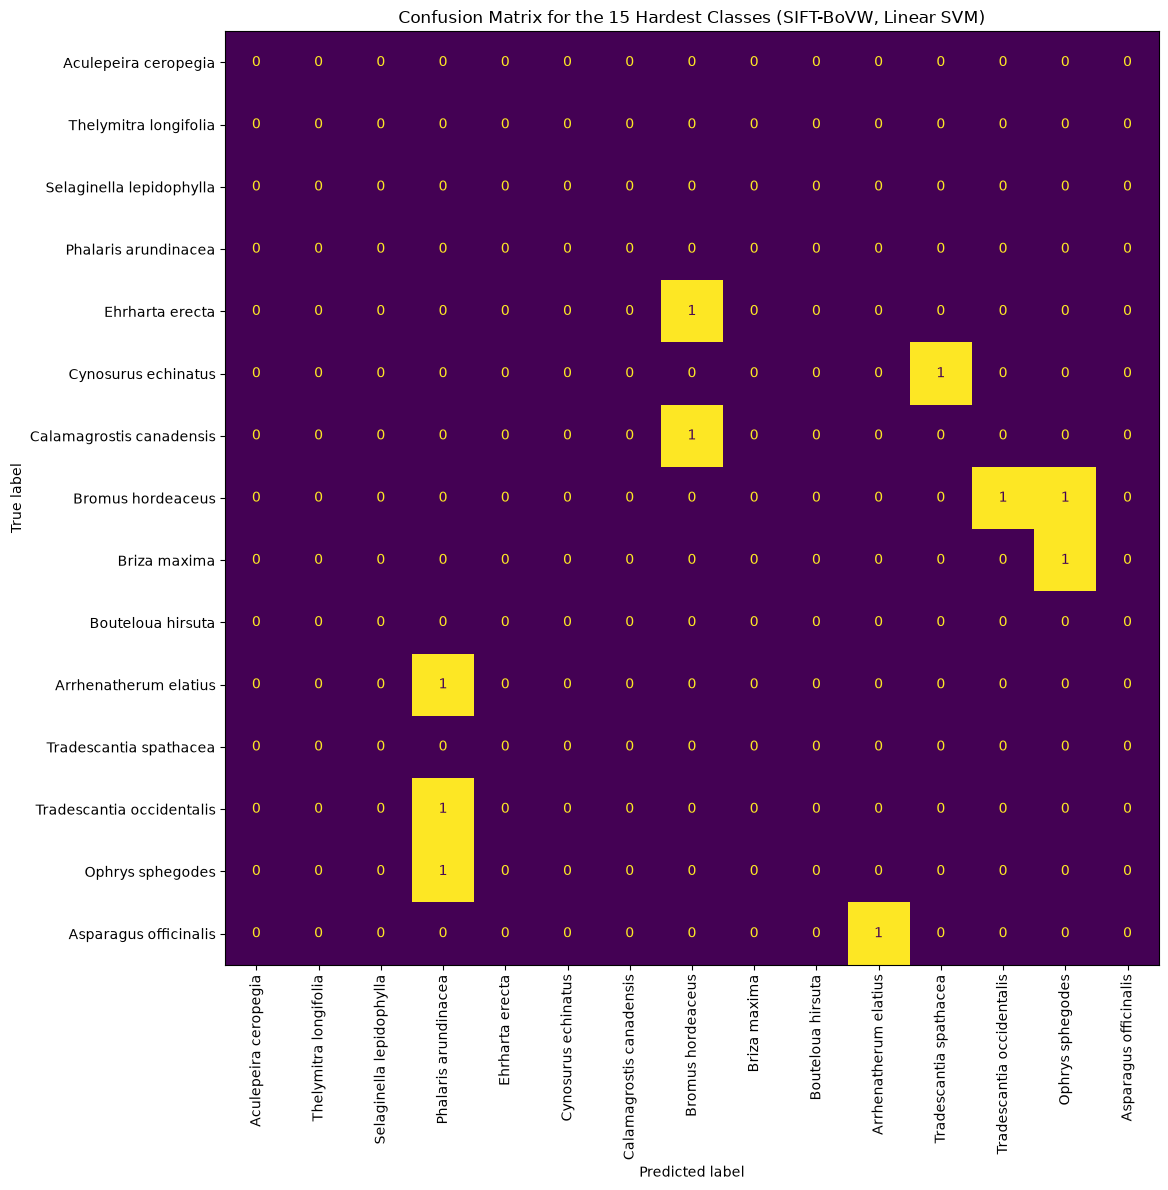

In [23]:
hardest_classes = class_statistics_df.head(15)["label"].to_numpy()
hardest_mask = np.isin(y_test, hardest_classes)

selected_confusion_matrix = confusion_matrix(
    y_test[hardest_mask], svm_predictions[hardest_mask], labels=hardest_classes
)
hardest_display_labels = [label_to_name.get(int(c), str(c)) for c in hardest_classes]

display = ConfusionMatrixDisplay(
    confusion_matrix=selected_confusion_matrix,
    display_labels=hardest_display_labels,
)

fig, ax = plt.subplots(figsize=(12, 12))
display.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("Confusion Matrix for the 15 Hardest Classes (SIFT-BoVW, Linear SVM)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "sift_bovw_svm_hardest_classes_confusion.png", dpi=150)
plt.show()

In [24]:
confusion_without_diagonal = full_confusion_matrix.copy()
np.fill_diagonal(confusion_without_diagonal, 0)

confused_pairs = []
classes = final_svm.classes_

for true_index in range(len(classes)):
    for pred_index in range(len(classes)):
        count = confusion_without_diagonal[true_index, pred_index]
        if count > 0:
            true_label = int(classes[true_index])
            pred_label = int(classes[pred_index])
            confused_pairs.append(
                {
                    "true_label": true_label,
                    "true_name": label_to_name.get(true_label, str(true_label)),
                    "predicted_label": pred_label,
                    "predicted_name": label_to_name.get(pred_label, str(pred_label)),
                    "count": int(count),
                }
            )

confused_pairs_df = (
    pd.DataFrame(confused_pairs)
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)
confused_pairs_df.to_csv(RESULTS_DIR / "sift_bovw_svm_confused_pairs.csv", index=False)
confused_pairs_df.head(20)

,true_label,true_name,predicted_label,predicted_name,count
0,383,Persicaria perfoliata,457,Achlys triphylla,4
1,86,Balsa tristrigella,70,Glenoides texanaria,4
2,278,Leratiomyces erythrocephalus,105,Phaedyma columella,4
3,66,Biston betularia,70,Glenoides texanaria,4
4,68,Chloroclystis inductata,70,Glenoides texanaria,4
5,44,Crambus perlella,224,Megaptera novaeangliae,3
6,154,Gypaetus barbatus,152,Geranoaetus albicaudatus,3
7,157,Mareca strepera,162,Cepphus columba,3
8,494,Dicksonia squarrosa,496,Telmatoblechnum serrulatum,3
9,273,Chondrostereum purpureum,8,Semibalanus balanoides,3


## 16. Random Forest confusion matrix and most-confused species pairs

Random Forest underperforms its own baseline on SIFT-BoVW (see Section 12),
but its error pattern is still reported here for completeness and
comparison with the Linear SVM's above. Skipped automatically if Section 11
(Random Forest) wasn't run.

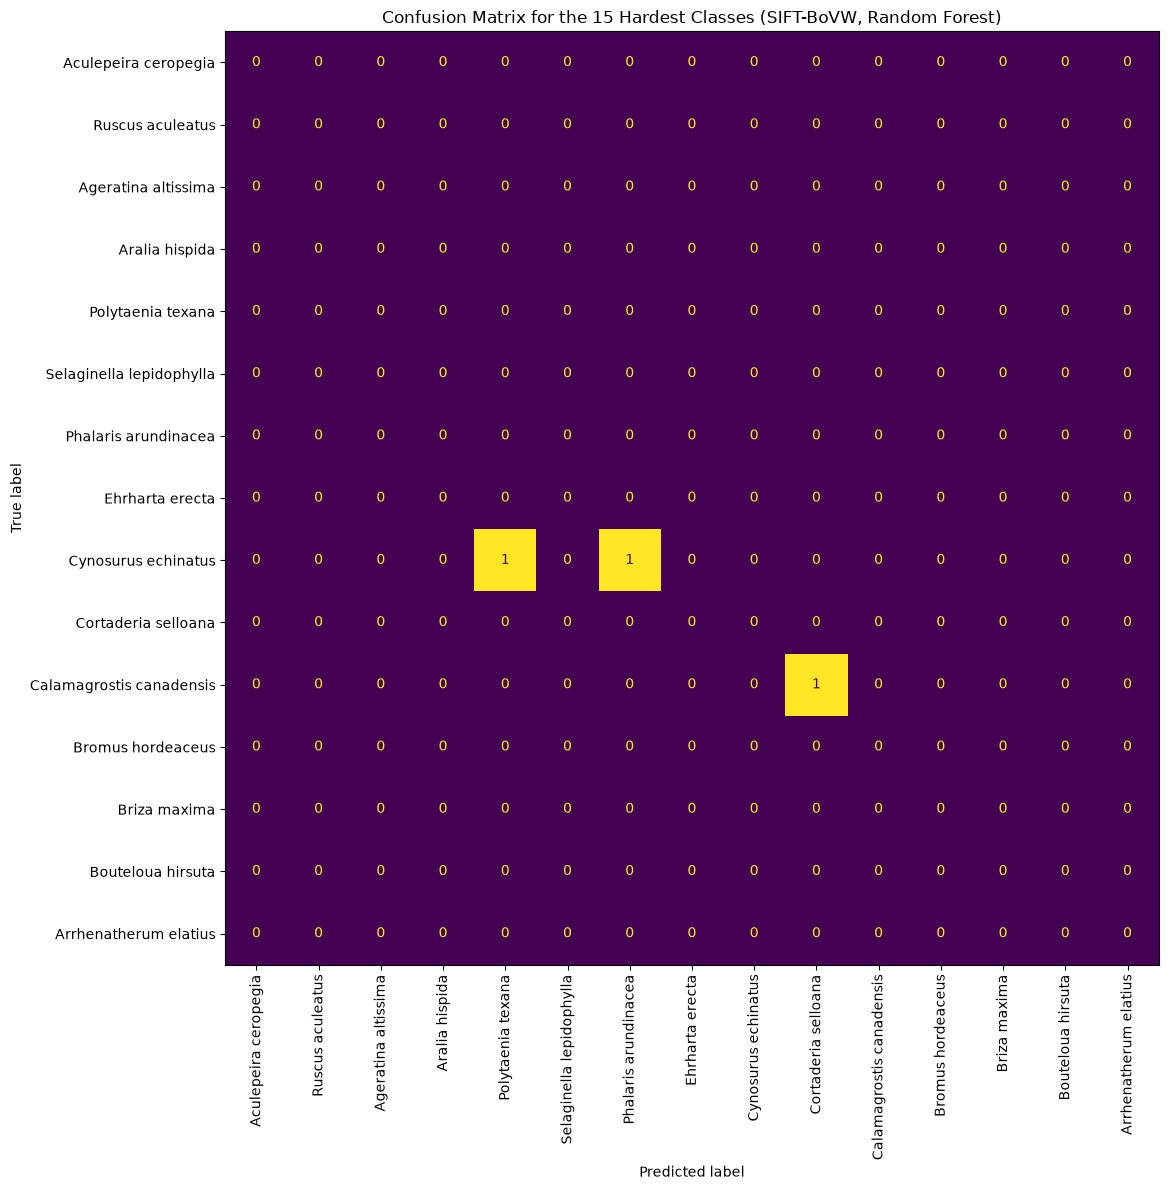

In [25]:
if "rf_test_results" in dir():
    rf_predictions = rf_test_results["predictions"]

    rf_confusion_matrix = confusion_matrix(
        y_test, rf_predictions, labels=random_forest.classes_
    )
    np.save(RESULTS_DIR / "sift_bovw_rf_confusion_matrix.npy", rf_confusion_matrix)

    rf_class_statistics = []
    for class_label in random_forest.classes_:
        class_mask = y_test == class_label
        class_predictions = rf_predictions[class_mask]
        class_accuracy = (
            np.mean(class_predictions == class_label) if class_mask.any() else np.nan
        )

        rf_class_statistics.append(
            {
                "label": class_label,
                "category_name": label_to_name.get(int(class_label), str(class_label)),
                "accuracy": class_accuracy,
                "error_rate": 1 - class_accuracy,
                "sample_count": int(class_mask.sum()),
            }
        )

    rf_class_statistics_df = (
        pd.DataFrame(rf_class_statistics)
        .sort_values("error_rate", ascending=False)
    )
    rf_class_statistics_df.to_csv(RESULTS_DIR / "sift_bovw_rf_per_class_accuracy.csv", index=False)

    rf_hardest_classes = rf_class_statistics_df.head(15)["label"].to_numpy()
    rf_hardest_mask = np.isin(y_test, rf_hardest_classes)

    rf_selected_confusion_matrix = confusion_matrix(
        y_test[rf_hardest_mask], rf_predictions[rf_hardest_mask], labels=rf_hardest_classes
    )
    rf_hardest_display_labels = [label_to_name.get(int(c), str(c)) for c in rf_hardest_classes]

    rf_display = ConfusionMatrixDisplay(
        confusion_matrix=rf_selected_confusion_matrix,
        display_labels=rf_hardest_display_labels,
    )

    fig, ax = plt.subplots(figsize=(12, 12))
    rf_display.plot(ax=ax, xticks_rotation=90, colorbar=False)
    plt.title("Confusion Matrix for the 15 Hardest Classes (SIFT-BoVW, Random Forest)")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "sift_bovw_rf_hardest_classes_confusion.png", dpi=150)
    plt.show()

    rf_confusion_without_diagonal = rf_confusion_matrix.copy()
    np.fill_diagonal(rf_confusion_without_diagonal, 0)

    rf_confused_pairs = []
    rf_classes = random_forest.classes_
    for true_index in range(len(rf_classes)):
        for pred_index in range(len(rf_classes)):
            count = rf_confusion_without_diagonal[true_index, pred_index]
            if count > 0:
                true_label = int(rf_classes[true_index])
                pred_label = int(rf_classes[pred_index])
                rf_confused_pairs.append(
                    {
                        "true_label": true_label,
                        "true_name": label_to_name.get(true_label, str(true_label)),
                        "predicted_label": pred_label,
                        "predicted_name": label_to_name.get(pred_label, str(pred_label)),
                        "count": int(count),
                    }
                )

    rf_confused_pairs_df = (
        pd.DataFrame(rf_confused_pairs)
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
    )
    rf_confused_pairs_df.to_csv(RESULTS_DIR / "sift_bovw_rf_confused_pairs.csv", index=False)
    rf_confused_pairs_df.head(20)
else:
    print("Random Forest section was skipped -- no RF confusion matrix to show.")

## 17. Visualise misclassified examples

A handful of the Linear SVM's misclassified test images, shown with their
true and predicted species names -- same presentation as
`traditional_classifier.ipynb`, for direct comparison in the report.

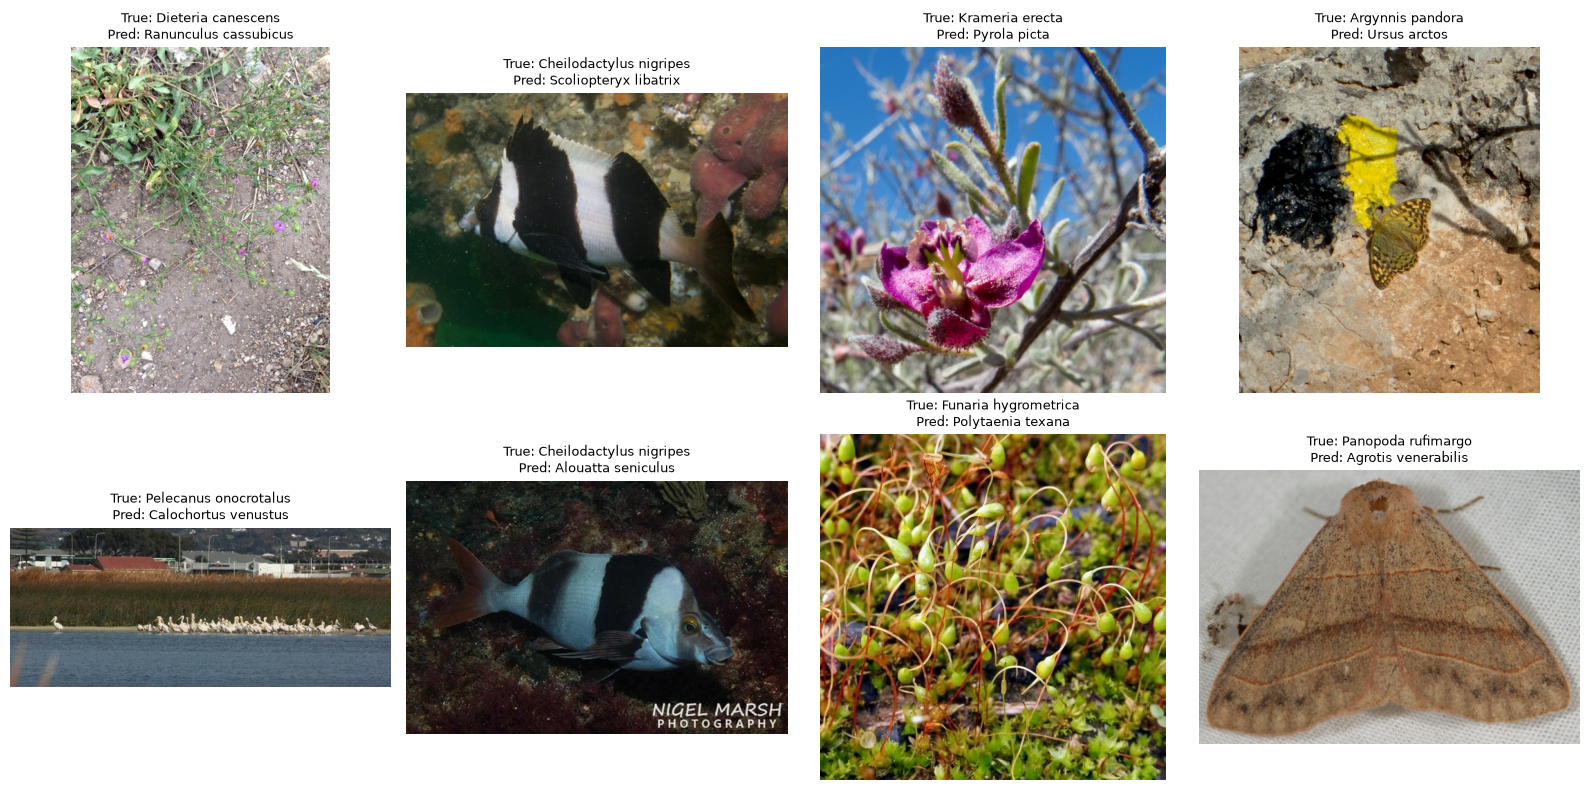

In [26]:
from PIL import Image as PILImage

N_EXAMPLES = 8
incorrect_mask = svm_predictions != y_test
rng = np.random.default_rng(config.RANDOM_SEED)

incorrect_indices = np.where(incorrect_mask)[0]
sample_indices = rng.choice(
    incorrect_indices, size=min(N_EXAMPLES, len(incorrect_indices)), replace=False
)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, idx in zip(axes.ravel(), sample_indices):
    image_path = config.DATA_RAW_ROOT / str(test_paths[idx])

    with PILImage.open(image_path) as image:
        ax.imshow(image.convert("RGB"))

    true_name = label_to_name.get(int(y_test[idx]), str(y_test[idx]))
    pred_name = label_to_name.get(int(svm_predictions[idx]), str(svm_predictions[idx]))

    ax.set_title(f"True: {true_name}\nPred: {pred_name}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "sift_bovw_svm_misclassified_examples.png", dpi=150)
plt.show()

## Summary

- Reimplemented the same SIFT extraction settings as `../features/sift.ipynb`
  (`cv2.SIFT_create(nfeatures=500)`, grayscale, `config.IMG_SIZE`-resized),
  then added the missing Bag-of-Visual-Words step: a `MiniBatchKMeans`
  vocabulary of 300 visual words, and per-image L2-normalised word-frequency
  histograms as the final 300-dimensional feature.
- Test-set results (500 classes, 5,000 test images): the nearest-centroid
  baseline reaches 3.58% top-1 / 11.80% top-5 -- notably higher than the
  HOG + colour baseline's 2.24% / 7.26%, suggesting SIFT-BoVW carries more
  raw discriminative signal on this task. Linear SVM (C=0.001, selected by
  validation macro-F1) reaches 3.72% top-1 / 10.24% top-5 / 0.0258 macro F1,
  the best top-1 accuracy of any traditional-classifier configuration tried
  so far (ahead of HOG + colour's Random Forest at 3.32%).
- Unlike the HOG + colour pipeline (where Random Forest was the stronger
  classifier), Random Forest on SIFT-BoVW reaches only 2.64% top-1 / 8.72%
  top-5 -- *below* its own trivial baseline. The same classifier
  configuration that worked well on one feature representation does not
  automatically transfer to another; this is discussed further in the
  report, along with possible retuning (e.g. shallower trees, different
  `max_features`) as future work rather than something fixed here given
  time constraints.
- (Optional) Concatenating SIFT-BoVW with the existing HOG + colour combined
  feature and retraining a Linear SVM (PCA(150)) reaches 2.96% top-1 / 10.10%
  top-5 / 0.0219 macro F1 -- *worse* than SIFT-BoVW alone on top-1. A likely
  explanation: the concatenated space is dominated by the 6180-dimensional
  HOG + colour block versus only 300 SIFT-BoVW dimensions, so a shared
  150-component PCA likely captures more of the weaker HOG + colour signal
  and dilutes SIFT-BoVW's stronger one, rather than combining their
  strengths. Full comparison saved to
  `outputs/sift_bovw_classifier/descriptor_comparison_with_sift.csv`.
- Error analysis (Sections 15-17): with only 10 test images per class, 381
  of 500 classes (76%) have 0% test accuracy under the Linear SVM, and 411
  of 500 (82%) under Random Forest -- both somewhat better than HOG +
  colour's SVM (410/500) but Random Forest here is worse than HOG +
  colour's RF (404/500), consistent with Random Forest underperforming on
  this feature set. As with HOG + colour, the most-confused species pairs
  and the visualised misclassified examples are frequently between
  visually and taxonomically unrelated species (e.g. a fish predicted as a
  primate, a butterfly predicted as a bear), reinforcing that the
  handcrafted feature representation -- not just the classifier -- is the
  main bottleneck on this fine-grained task.
- All outputs (feature caches, hyperparameter search, comparison tables,
  confusion matrices, most-confused species pairs, misclassified examples,
  and the fitted models) are saved under `outputs/sift_bovw_classifier/` and
  the three `outputs/*_sift_bovw_features.npz` cache files.